In [84]:
import os
path = os.getenv('DATA_PATH')
token = os.getenv('API_TOKEN')

In [85]:
from a3em.datasets import Arden
X_train, X_test, y_train, y_test = Arden.load_data(token, path, random_state=123, shuffle=True) 

prefetch complete
extracting features


100%|██████████| 62/62 [02:01<00:00,  1.96s/it]

features extracted


In [86]:
X_train.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_17,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26
1597,37.109375,168.076441,138.191270,22.460938,325.195312,-10.095732,-8.033260,-172.262615,215.194218,-24.258278,...,0.011935,0.004785,0.002983,0.001664,0.001155,0.000971,0.000508,0.000177,1.229715e-04,9.892058e-05
1076,22.460938,112.266283,101.382660,21.484375,115.234375,1.678093,9.648725,-308.668280,200.521588,39.115252,...,0.000179,0.000078,0.000046,0.000035,0.000021,0.000015,0.000006,0.000002,7.844644e-07,6.140963e-07
1725,21.484375,129.674382,107.133586,21.484375,122.070312,1.952452,6.507698,-248.942476,219.149171,9.620668,...,0.000916,0.000324,0.000152,0.000108,0.000055,0.000023,0.000013,0.000005,1.313371e-06,3.777111e-07
421,21.484375,130.559090,111.473957,20.507812,136.718750,-0.740542,4.986019,-242.194626,215.758272,16.257972,...,0.001683,0.001010,0.000831,0.000341,0.000318,0.000233,0.000143,0.000106,9.186665e-05,8.920954e-05
569,29.296875,166.452260,126.153820,24.414062,250.976562,-9.380498,-4.567325,-242.964561,222.341581,-16.900579,...,0.002679,0.001492,0.000979,0.000949,0.000275,0.000162,0.000085,0.000031,2.116444e-05,1.772959e-05


In [87]:
y_train.head()

1597    0
1076    1
1725    1
421     1
569     0
Name: label, dtype: int64

In [88]:
X_train.to_csv('./data/train/features.csv')
X_test.to_csv('./data/test/features.csv')
y_train.to_csv('./data/train/labels.csv')
y_test.to_csv('./data/test/labels.csv')

## Analysis

In [89]:
import pandas as pd

In [90]:
train_features = pd.read_csv('./data/train/features.csv')
test_feature = pd.read_csv('./data/test/features.csv')
train_labels = pd.read_csv('./data/train/labels.csv')
test_labels = pd.read_csv('./data/test/labels.csv')

features_aggregate = pd.concat([train_features, test_feature], ignore_index=True)
labels_aggregate = pd.concat([train_labels, test_labels], ignore_index=True)

In [91]:
labels_aggregate['label'].value_counts()

label
0    1141
1     706
Name: count, dtype: int64

In [92]:
# Combine
df = train_features.copy().drop(columns=['Unnamed: 0'])
df['label'] = train_labels['label']

In [93]:
df.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26,label
0,37.109375,168.076441,138.191270,22.460938,325.195312,-10.095732,-8.033260,-172.262615,215.194218,-24.258278,...,0.004785,0.002983,0.001664,0.001155,0.000971,0.000508,0.000177,1.229715e-04,9.892058e-05,0
1,22.460938,112.266283,101.382660,21.484375,115.234375,1.678093,9.648725,-308.668280,200.521588,39.115252,...,0.000078,0.000046,0.000035,0.000021,0.000015,0.000006,0.000002,7.844644e-07,6.140963e-07,1
2,21.484375,129.674382,107.133586,21.484375,122.070312,1.952452,6.507698,-248.942476,219.149171,9.620668,...,0.000324,0.000152,0.000108,0.000055,0.000023,0.000013,0.000005,1.313371e-06,3.777111e-07,1
3,21.484375,130.559090,111.473957,20.507812,136.718750,-0.740542,4.986019,-242.194626,215.758272,16.257972,...,0.001010,0.000831,0.000341,0.000318,0.000233,0.000143,0.000106,9.186665e-05,8.920954e-05,1
4,29.296875,166.452260,126.153820,24.414062,250.976562,-9.380498,-4.567325,-242.964561,222.341581,-16.900579,...,0.001492,0.000979,0.000949,0.000275,0.000162,0.000085,0.000031,2.116444e-05,1.772959e-05,0


### Compute Summary Statistics

In [94]:
summary = df.groupby("label").mean()

std_summary = df.groupby("label").std()

comparison = pd.DataFrame({
    "Background Mean": df[df["label"] == 0].mean(),
    "Rumble Mean": df[df["label"] == 1].mean(),
    "Background Std": df[df["label"] == 0].std(),
    "Rumble Std": df[df["label"] == 1].std()
})

comparison = comparison.drop(index="label")
comparison

,Background Mean,Rumble Mean,Background Std,Rumble Std
peak_freq,32.008348,24.028891,10.366742,2.635764
centroid,146.346381,116.640743,31.116973,14.026849
bandwidth,122.476863,98.080163,19.505869,11.575791
freq_5,21.982379,23.031877,6.754568,2.276788
freq_95,212.015608,125.673198,72.754636,14.199880
hnr,-7.685528,-1.420115,6.327998,3.830945
hnr_low,-6.215134,3.271823,6.842976,4.368270
mfcc_1,-233.931028,-287.597578,90.785931,40.176587
mfcc_2,218.329129,219.658948,15.858616,9.714744
mfcc_3,-3.519733,29.625977,29.132708,16.738205


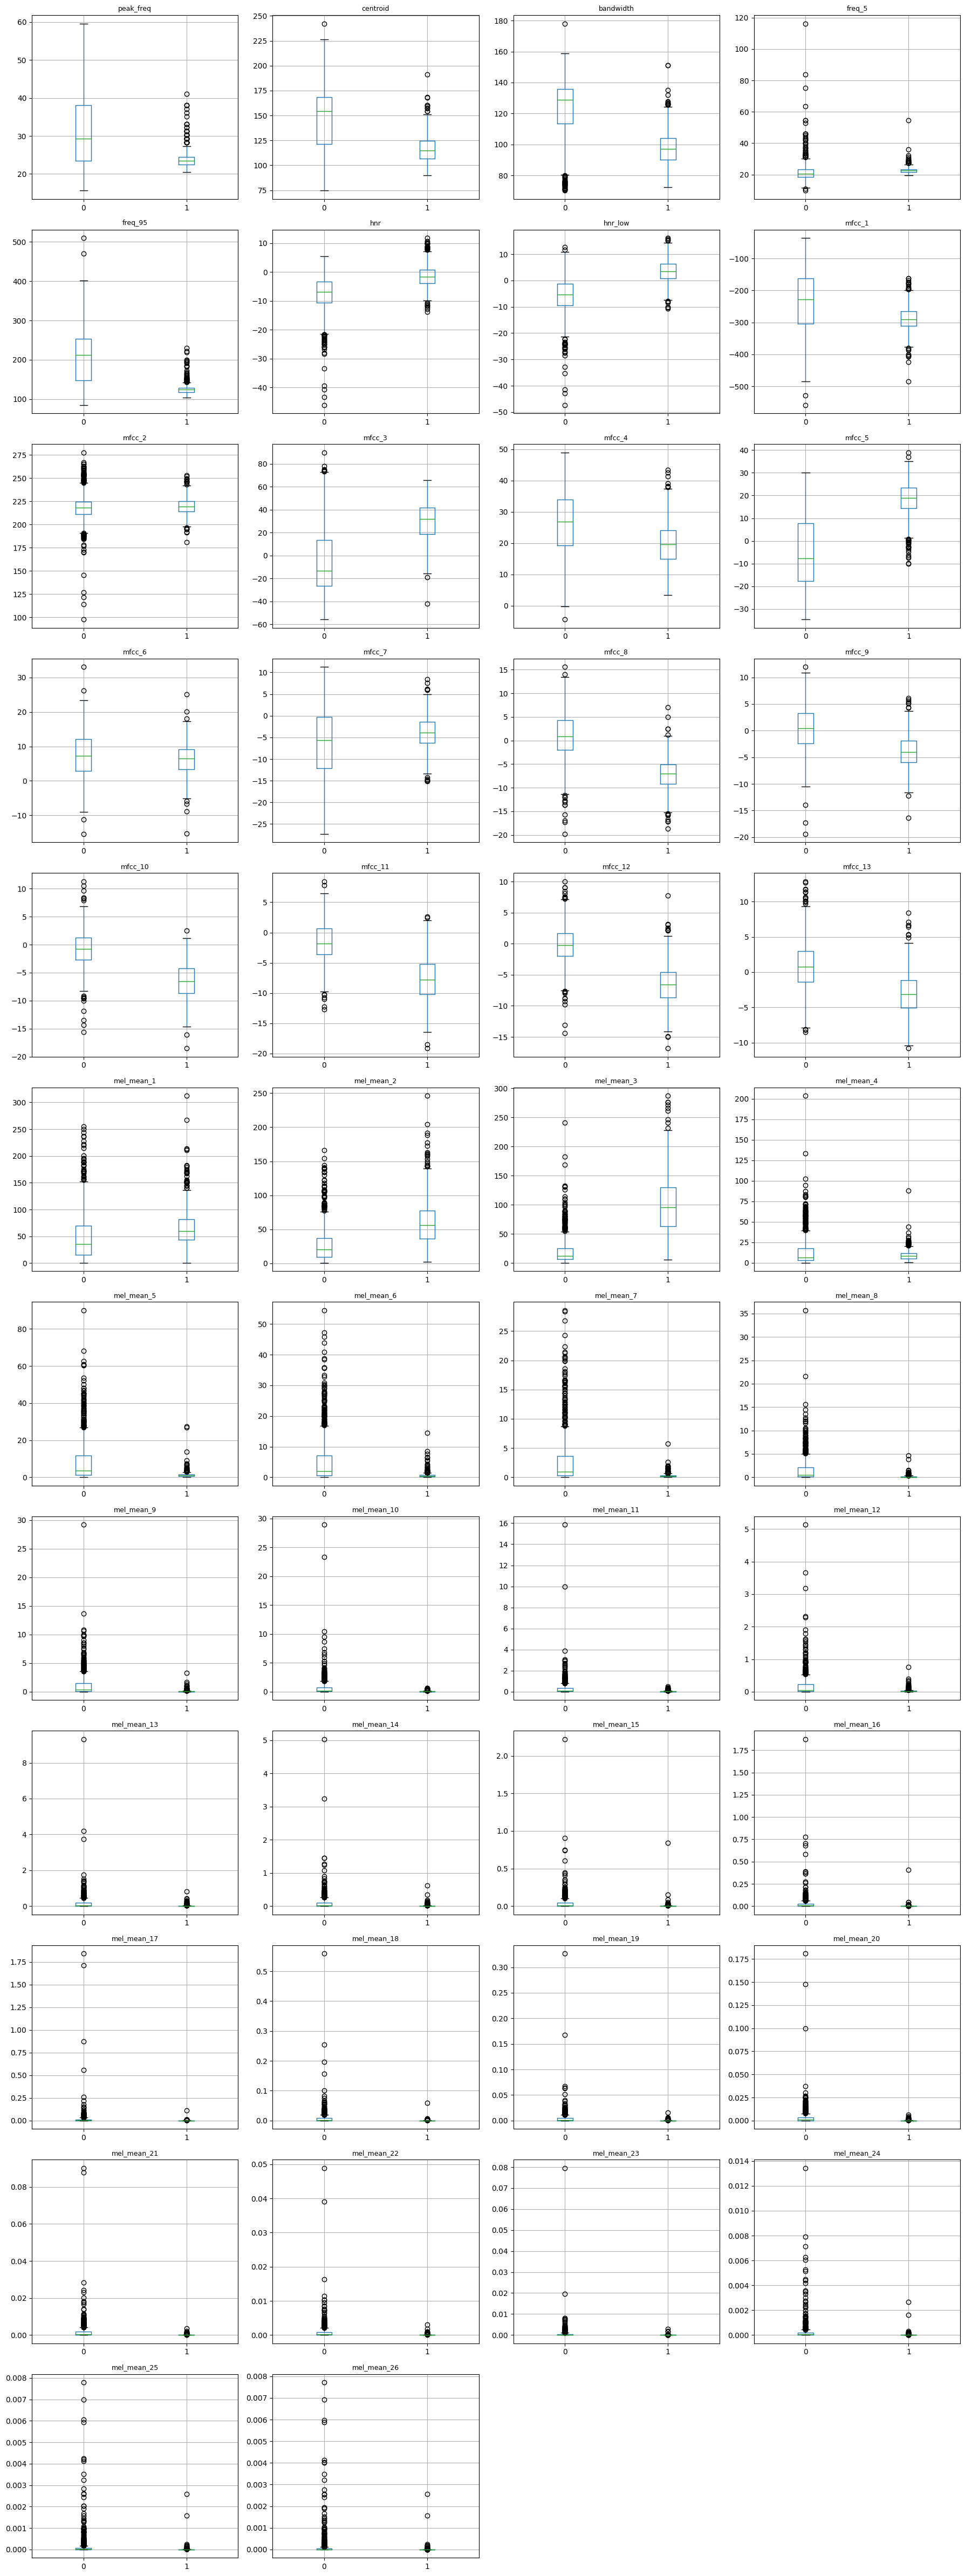

In [95]:
import matplotlib.pyplot as plt

# List of feature columns (everything except the label)
feature_cols = df.columns.drop("label")

# Determine the layout of the figure
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(feature_cols):

    df.boxplot(
        column=feature,
        by="label",
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("")
plt.tight_layout()

plt.show()

### Statistical Testing
Because our data does not follow a uniform distribution, we will use a **Mann-Whitney U test**

In [96]:
from scipy.stats import mannwhitneyu

In [97]:
# run the test on every feature
results = []

feature_cols = df.columns.drop("label")

for feature in feature_cols:

    background = df[df["label"] == 0][feature]
    rumble = df[df["label"] == 1][feature]

    stat, p = mannwhitneyu(
        background,
        rumble,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "U Statistic": stat,
        "P Value": p
    })

results = pd.DataFrame(results)

In [98]:
# rank the features
results = results.sort_values("P Value")

results.head(20)

,Feature,U Statistic,P Value
22,mel_mean_3,31939.0,9.471857e-178
11,mfcc_5,40411.0,6.967646e-165
14,mfcc_8,477494.0,9.390401e-165
18,mfcc_12,476557.0,2.318508e-163
17,mfcc_11,471015.0,3.015906e-155
16,mfcc_10,468727.0,5.867551e-152
6,hnr_low,49697.0,2.429241e-151
4,freq_95,457520.5,2.173641e-136
2,bandwidth,434511.0,5.130885e-107
9,mfcc_3,89796.0,1.365281e-99


In [99]:
results["Significant"] = results["P Value"] < 0.05

results.head(20)

,Feature,U Statistic,P Value,Significant
22,mel_mean_3,31939.0,9.471857e-178,True
11,mfcc_5,40411.0,6.967646e-165,True
14,mfcc_8,477494.0,9.390401e-165,True
18,mfcc_12,476557.0,2.318508e-163,True
17,mfcc_11,471015.0,3.015906e-155,True
16,mfcc_10,468727.0,5.867551e-152,True
6,hnr_low,49697.0,2.429241e-151,True
4,freq_95,457520.5,2.173641e-136,True
2,bandwidth,434511.0,5.130885e-107,True
9,mfcc_3,89796.0,1.365281e-99,True


In [100]:
results["Significant"].value_counts()

Significant
True    46
Name: count, dtype: int64

In [101]:
results[results["Significant"] == False]

,Feature,U Statistic,P Value,Significant


To reduce the chance of luck in our analysis, we will use a **Benjamini–Hochberg false discovery rate (FDR)** to adjust the p-va;ues

In [102]:
from statsmodels.stats.multitest import multipletests

results["Adjusted P"] = multipletests(
    results["P Value"],
    method="fdr_bh"
)[1]

results["Significant (FDR)"] = results["Adjusted P"] < 0.05

### Logistic Regression

In [103]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(1477, 46)
(370, 46)
label
0    904
1    573
Name: count, dtype: int64
label
0    237
1    133
Name: count, dtype: int64


In [104]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [105]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [106]:
y_pred = model.predict(X_test_scaled)

### Classifier Evaluation

In [107]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[233   4]
 [  3 130]]


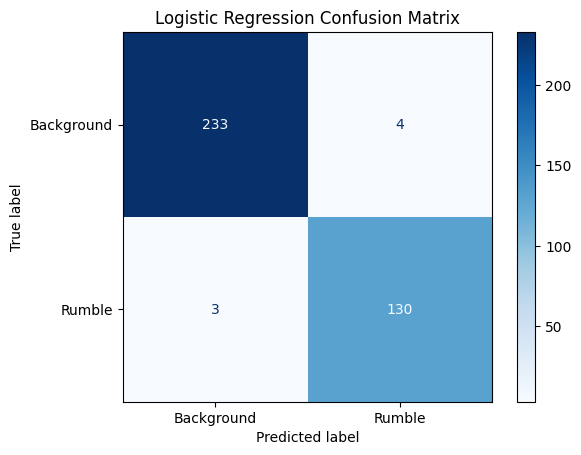

In [108]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Background", "Rumble"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [109]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       237
           1       0.97      0.98      0.97       133

    accuracy                           0.98       370
   macro avg       0.98      0.98      0.98       370
weighted avg       0.98      0.98      0.98       370



In [110]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.999


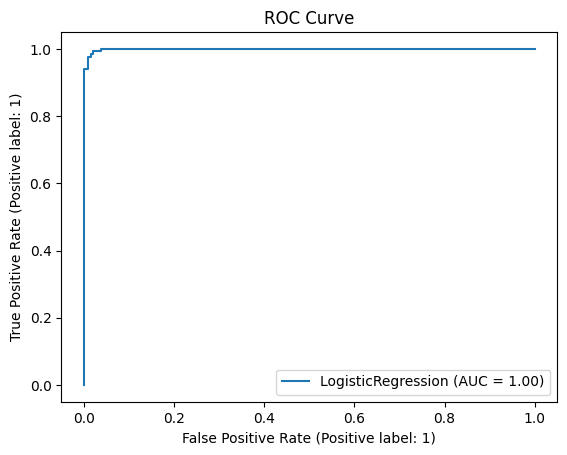

In [111]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve")
plt.show()

### Feature Importance from Logistic Regression

In [112]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute Coefficient
6,hnr_low,2.499537,2.499537
8,mfcc_2,-1.279393,1.279393
11,mfcc_5,1.219335,1.219335
4,freq_95,-1.083449,1.083449
22,mel_mean_3,1.082266,1.082266
7,mfcc_1,-1.001561,1.001561
0,peak_freq,-0.947921,0.947921
13,mfcc_7,-0.793079,0.793079
15,mfcc_9,-0.784874,0.784874
5,hnr,0.781501,0.781501


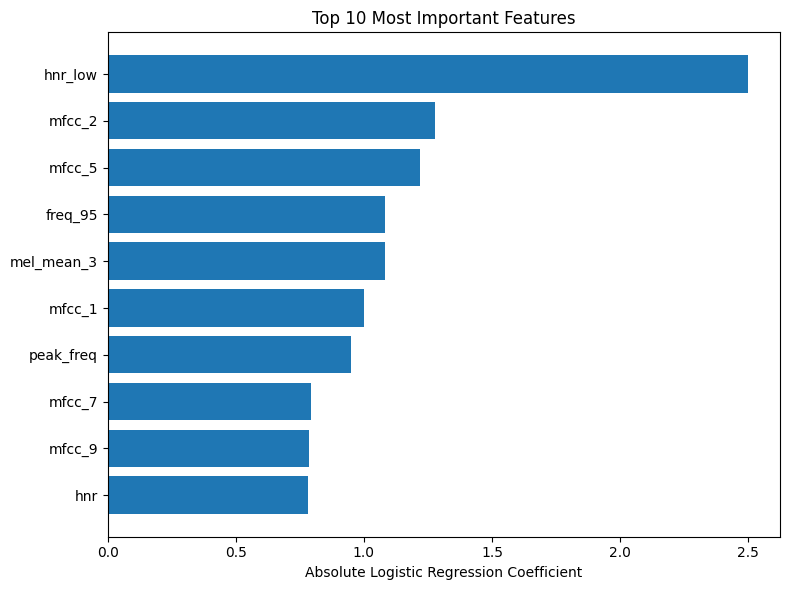

In [113]:
import matplotlib.pyplot as plt

top10 = coefficients.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Absolute Coefficient"]
)

plt.xlabel("Absolute Logistic Regression Coefficient")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [114]:
feature_summary = coefficients.merge(
    results,
    on="Feature"
)

feature_summary = feature_summary.sort_values(
    "Absolute Coefficient",
    ascending=False
)

feature_summary.head(10)

,Feature,Coefficient,Absolute Coefficient,U Statistic,P Value,Significant,Adjusted P,Significant (FDR)
0,hnr_low,2.499537,2.499537,49697.0,2.429241e-151,True,1.596358e-150,True
1,mfcc_2,-1.279393,1.279393,238835.0,1.160206e-02,True,1.185988e-02,True
2,mfcc_5,1.219335,1.219335,40411.0,6.967646e-165,True,1.439861e-163,True
3,freq_95,-1.083449,1.083449,457520.5,2.173641e-136,True,1.249843e-135,True
4,mel_mean_3,1.082266,1.082266,31939.0,9.471857e-178,True,4.357054e-176,True
5,mfcc_1,-1.001561,1.001561,357089.0,1.148157e-34,True,1.320381e-34,True
6,peak_freq,-0.947921,0.947921,385703.0,4.612453e-57,True,6.429481e-57,True
7,mfcc_7,-0.793079,0.793079,217538.0,2.099215e-07,True,2.245671e-07,True
8,mfcc_9,-0.784874,0.784874,416469.0,1.603420e-86,True,5.268380e-86,True
9,hnr,0.781501,0.781501,97328.0,4.334879e-91,True,1.533880e-90,True


### Cross Validation with Random Forest

In [115]:
from sklearn.ensemble import RandomForestClassifier

In [116]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [117]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [118]:
rf_pred = rf_model.predict(X_test)

In [119]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99       237
           1       0.96      1.00      0.98       133

    accuracy                           0.98       370
   macro avg       0.98      0.99      0.98       370
weighted avg       0.98      0.98      0.98       370



### RandomForest Feature Importance

In [120]:
import pandas as pd

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
22,mel_mean_3,0.132370
6,hnr_low,0.110941
18,mfcc_12,0.091141
4,freq_95,0.082927
14,mfcc_8,0.074737
17,mfcc_11,0.062105
11,mfcc_5,0.058509
16,mfcc_10,0.042013
2,bandwidth,0.041902
0,peak_freq,0.029073


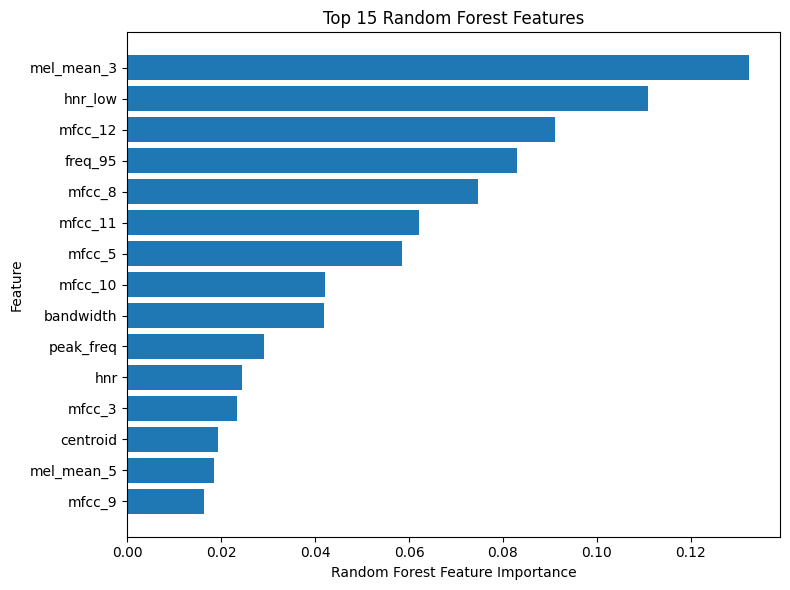

In [121]:
import matplotlib.pyplot as plt

top15 = rf_importance.head(15)

plt.figure(figsize=(8,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [122]:
# Mann-Whitney U ranking
mw_rank = results.copy()

mw_rank = mw_rank.sort_values("P Value")

mw_rank["MW Rank"] = range(1, len(mw_rank)+1)

mw_rank = mw_rank[[
    "Feature",
    "MW Rank",
    "P Value"
]]

# Logistic Regression ranking
lr_rank = coefficients.copy()

lr_rank = lr_rank.sort_values(
    "Absolute Coefficient",
    ascending=False
)

lr_rank["LR Rank"] = range(1, len(lr_rank)+1)

lr_rank = lr_rank[[
    "Feature",
    "Coefficient",
    "Absolute Coefficient",
    "LR Rank"
]]

# Random Forest ranking
rf_rank = rf_importance.copy()

rf_rank = rf_rank.sort_values(
    "Importance",
    ascending=False
)

rf_rank["RF Rank"] = range(1, len(rf_rank)+1)

rf_rank = rf_rank[[
    "Feature",
    "Importance",
    "RF Rank"
]]

# merge
comparison = (
    mw_rank
    .merge(lr_rank, on="Feature")
    .merge(rf_rank, on="Feature")
)

# add overall ranking
comparison["Average Rank"] = (
    comparison["MW Rank"] +
    comparison["LR Rank"] +
    comparison["RF Rank"]
) / 3
comparison = comparison.sort_values("Average Rank")
comparison = comparison[[
    "Feature",
    "P Value",
    "Coefficient",
    "Importance",
    "MW Rank",
    "LR Rank",
    "RF Rank",
    "Average Rank"
]]

comparison.head(20)

,Feature,P Value,Coefficient,Importance,MW Rank,LR Rank,RF Rank,Average Rank
0,mel_mean_3,9.471857e-178,1.082266,0.132370,1,5,1,2.333333
6,hnr_low,2.429241e-151,2.499537,0.110941,7,1,2,3.333333
1,mfcc_5,6.967646e-165,1.219335,0.058509,2,3,7,4.000000
7,freq_95,2.173641e-136,-1.083449,0.082927,8,4,4,5.333333
2,mfcc_8,9.390401e-165,-0.680578,0.074737,3,11,5,6.333333
5,mfcc_10,5.867551e-152,-0.611664,0.042013,6,12,8,8.666667
4,mfcc_11,3.015906e-155,-0.466308,0.062105,5,21,6,10.666667
12,hnr,4.334879e-91,0.781501,0.024485,13,10,11,11.333333
13,mfcc_9,1.603420e-86,-0.784874,0.016420,14,9,15,12.666667
3,mfcc_12,2.318508e-163,0.056373,0.091141,4,38,3,15.000000
